# Heart Score + Arbitrary Reverse Initial Distribution

`reverse_test.ipynb`의 실험 세팅을 최대한 유지하되, reverse 과정의 시작점 `x_T`만 바꿔보는 실험입니다.

- score 함수: 하트 데이터셋으로부터 얻은 GMM exact score 그대로 사용
- solver: Euler-Maruyama만 사용
- 비교 대상: 실제 heart forward로 얻은 `x_T`와, 임의로 만든 여러 시작분포 `q(x)`
- 목적: reverse SDE의 이론적 초기조건 `x_T ~ p_T(x) ~= N(0, I)`에서 벗어나면 복원 결과가 어떻게 달라지는지 확인


## 실험 아이디어

Reverse SDE는 `t=T`에서의 분포가 forward process의 최종 분포 `p_T(x)`라고 가정하고 설계됩니다. 여기서는 score는 heart score로 고정하고, 시작 샘플만 아래처럼 바꿉니다.

| 시작분포 q(x) | 기대되는 현상 |
|---|---|
| `heart_forward_xT` | 올바른 기준선 |
| `N(0, 0.9^2 I)` | 표준정규와 비슷해서 비교적 정상 작동 |
| `N(0, 5I)` | 너무 퍼진 시작점이 score에 의해 강하게 끌림 |
| `N((3, 3), I)` | 치우친 시작점 때문에 비대칭/복원 실패 가능 |
| `Uniform([-3, 3]^2)` | 가우시안과 다른 모양이라 오차 누적 가능 |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

rng = np.random.default_rng(42)

# ── dataset setting: reverse_test.ipynb와 동일 ───────────────────────────────
def make_samples(means, std, n_per_mode):
    return np.vstack([mu + rng.standard_normal((n_per_mode, 2)) * std for mu in means])

# Heart
heart_t = np.linspace(0, 2 * np.pi, 20, endpoint=False)
heart_means = (
    np.column_stack(
        [
            16 * np.sin(heart_t) ** 3,
            13 * np.cos(heart_t) - 5 * np.cos(2 * heart_t) - 2 * np.cos(3 * heart_t) - np.cos(4 * heart_t),
        ]
    )
    / 10
)

heart_std = 0.07
heart_x0 = make_samples(heart_means, std=heart_std, n_per_mode=80)
n_samples = len(heart_x0)

# ── Noise schedule: reverse_test.ipynb와 동일 ────────────────────────────────
T = 500
_beta_start = 1e-4
_beta_end = 0.02


def beta_fn(t):
    """t in [0, T-1] -> beta (linear schedule)."""
    t = np.clip(t, 0, T - 1)
    return _beta_start + (_beta_end - _beta_start) * t / (T - 1)


def alpha_bar_fn(t):
    """t in [0, T-1] -> alpha_bar(t) = exp(-int_0^t beta(s) ds)."""
    t = np.clip(t, 0, T - 1)
    a = _beta_start
    b = (_beta_end - _beta_start) / (T - 1)
    return np.exp(-(a * t + 0.5 * b * t**2))


def sigma2_fn(t):
    """t in [0, T-1] -> sigma^2(t) = 1 - alpha_bar(t)."""
    return 1.0 - alpha_bar_fn(t)


SAVE_STEPS = [0, 100, 200, 300, 400, 500]
t_arr = np.arange(T, -1, -1)

In [2]:
def plot_steps(traj, steps=None, order="asc", color="#d62728", title=""):
    """스텝별 분포 시각화."""
    if steps is None:
        steps = sorted(traj.keys())

    if order == "asc":
        steps = list(steps)
    elif order == "desc":
        steps = list(reversed(steps))
    else:
        raise ValueError(f"order must be 'asc' or 'desc', got {order!r}")

    fig, axes = plt.subplots(1, len(steps), figsize=(3 * len(steps), 3))
    if len(steps) == 1:
        axes = [axes]

    for ax, t in zip(axes, steps):
        pts = traj.get(t)
        if pts is not None:
            ax.scatter(*pts.T, s=4, alpha=0.35, c=color)
        ax.scatter(*heart_means.T, s=18, c="black", marker="x", linewidths=1.0, alpha=0.7)
        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)
        ax.set_aspect("equal")
        ax.set_title(f"t={t}")

    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


def plot_initial_distributions(initials, cols=3):
    names = list(initials.keys())
    rows = int(np.ceil(len(names) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, name in zip(axes, names):
        pts = initials[name]
        ax.scatter(*pts.T, s=4, alpha=0.35)
        ax.set_xlim(-5, 5)
        ax.set_ylim(-5, 5)
        ax.set_aspect("equal")
        ax.set_title(name)

    for ax in axes[len(names):]:
        ax.axis("off")

    fig.suptitle("Reverse start distribution q(x)", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


## Forward baseline

기존 실험처럼 하트 데이터셋을 forward SDE로 보낸 뒤 얻은 `x_T`를 기준선으로 둡니다. 이 기준선은 reverse SDE가 기대하는 시작 조건에 가장 가깝습니다.


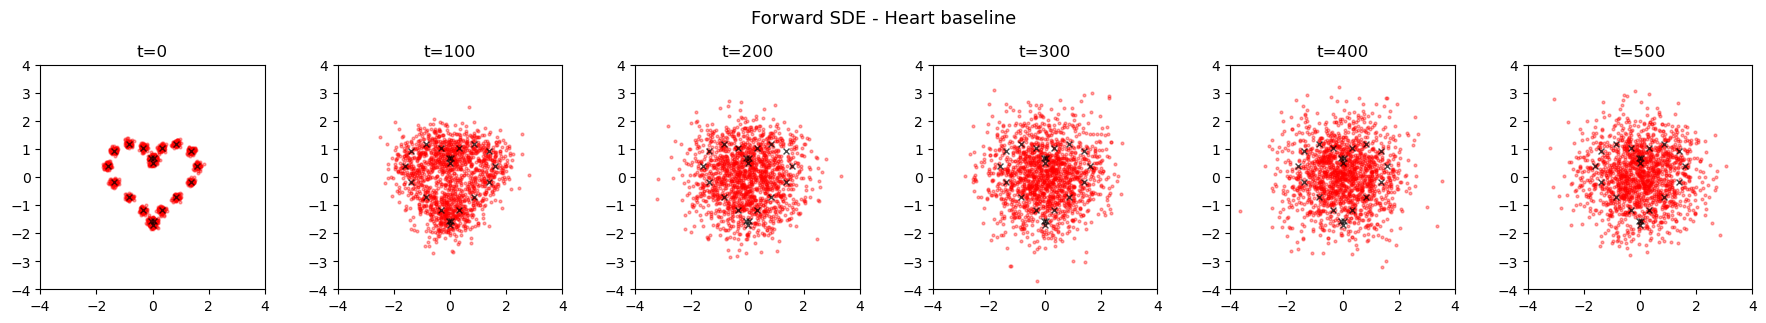

In [3]:
def forward_sde(x0):
    saved = {0: x0.copy()}
    x = x0.copy()
    for i in range(T):
        b = beta_fn(i)
        x = x * (1 - 0.5 * b) + np.sqrt(b) * rng.standard_normal(x.shape)
        saved[i + 1] = x.copy()
    return saved


heart_forward = forward_sde(heart_x0)
plot_steps(heart_forward, steps=SAVE_STEPS, order="asc", color="red", title="Forward SDE - Heart baseline")


## Heart GMM exact score

`reverse_test.ipynb`의 Case 0과 동일한 score입니다. 시작분포만 바꾸고 score는 이 함수를 계속 사용합니다.


In [4]:
def gmm_score(x, t, means, var):
    ab = alpha_bar_fn(t)
    s2 = sigma2_fn(t)
    mu_t = np.sqrt(ab) * means
    var_t = ab * var + s2

    diff = x[:, None, :] - mu_t[None, :, :]
    log_pk = -(diff**2).sum(-1) / (2 * var_t)
    log_pk -= log_pk.max(1, keepdims=True)

    wk = np.exp(log_pk)
    wk /= wk.sum(1, keepdims=True)

    score_k = -diff / var_t
    return (wk[:, :, None] * score_k).sum(1)


heart_score = partial(gmm_score, means=heart_means, var=heart_std**2)


## Euler reverse solver

solver는 Euler-Maruyama만 사용합니다. `reverse_test.ipynb`의 식과 구현을 그대로 가져왔습니다.


In [5]:
def reverse_euler(x_T, t_arr, score_fn):
    traj = {int(t_arr[0]): x_T.copy()}
    x = x_T.copy()
    dt = -1

    for t in t_arr[1:]:
        b = beta_fn(t)
        s = score_fn(x, t)
        x = x + b * (-0.5 * x - s) * dt + np.sqrt(b) * rng.standard_normal(x.shape)
        traj[int(t)] = x.copy()

    return traj


## 임의 시작분포 만들기

첨부 이미지의 예시를 반영해서 표준정규에 가까운 분포, 훨씬 퍼진 분포, 치우친 분포, 완전히 다른 모양의 uniform 분포를 만듭니다.


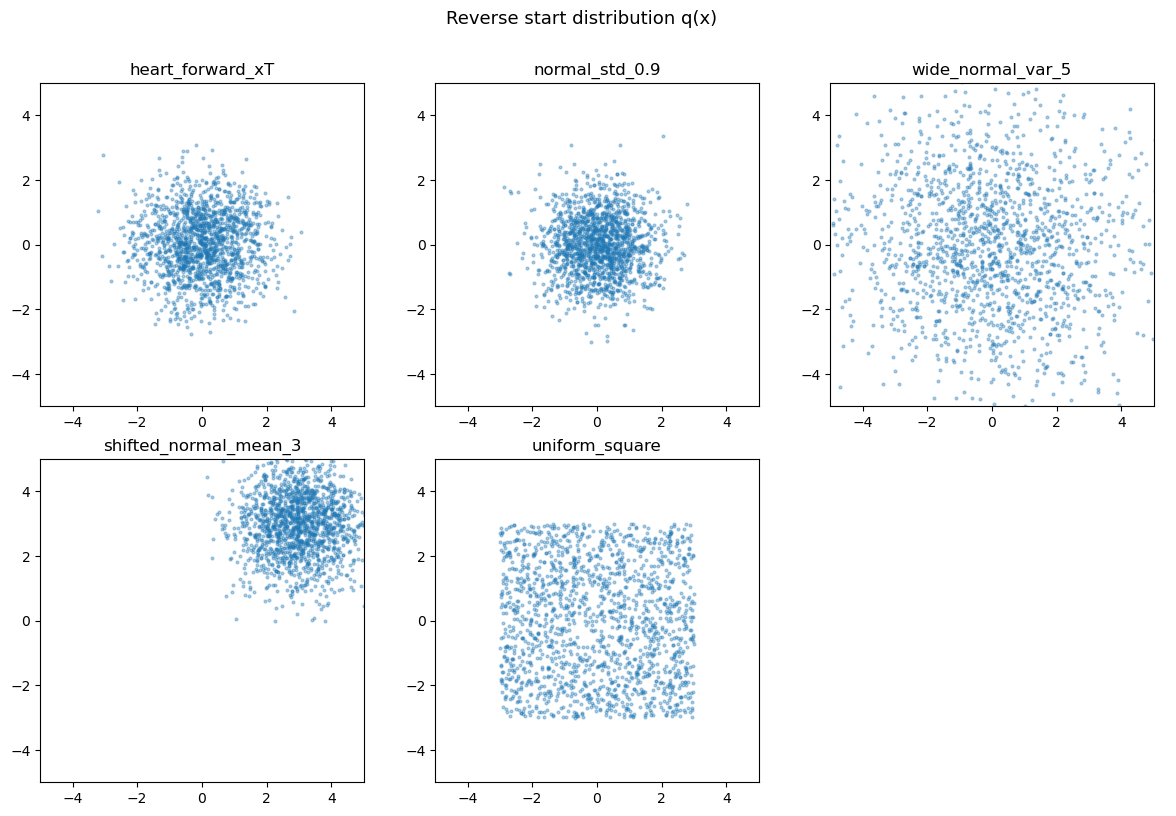

In [6]:
def make_reverse_initials(n):
    return {
        "heart_forward_xT": heart_forward[T].copy(),
        "normal_std_0.9": rng.normal(loc=0.0, scale=0.9, size=(n, 2)),
        "wide_normal_var_5": rng.normal(loc=0.0, scale=np.sqrt(5.0), size=(n, 2)),
        "shifted_normal_mean_3": rng.normal(loc=3.0, scale=1.0, size=(n, 2)),
        "uniform_square": rng.uniform(low=-3.0, high=3.0, size=(n, 2)),
    }


initials = make_reverse_initials(n_samples)
plot_initial_distributions(initials)


## Reverse 실행

모든 시작분포에 대해 같은 하트 score와 같은 Euler solver를 적용합니다.


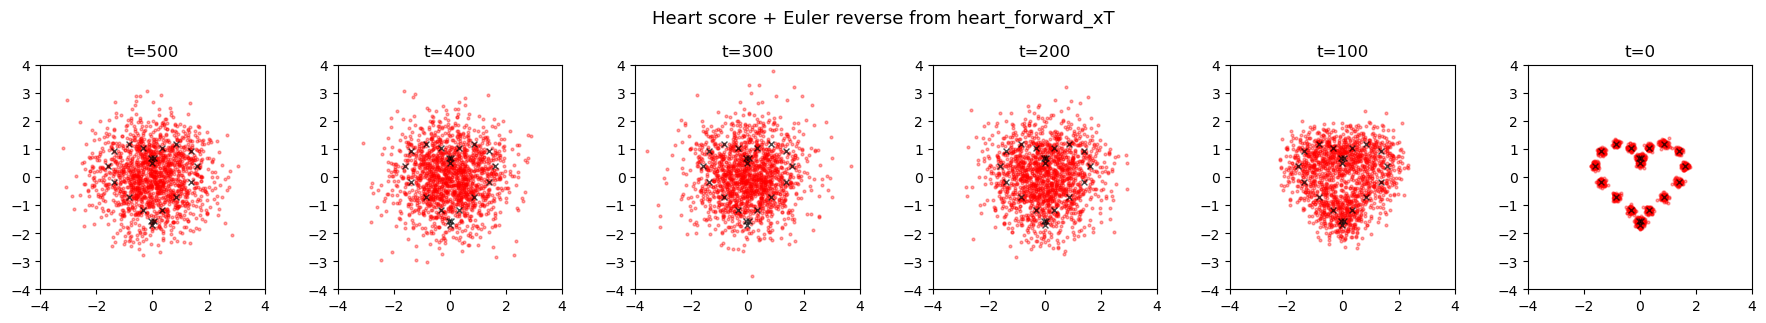

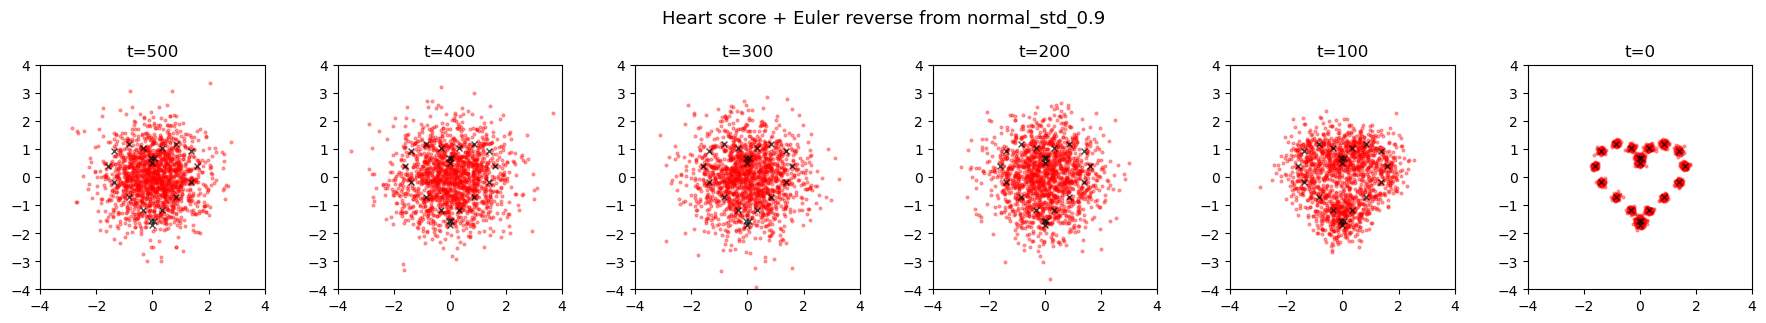

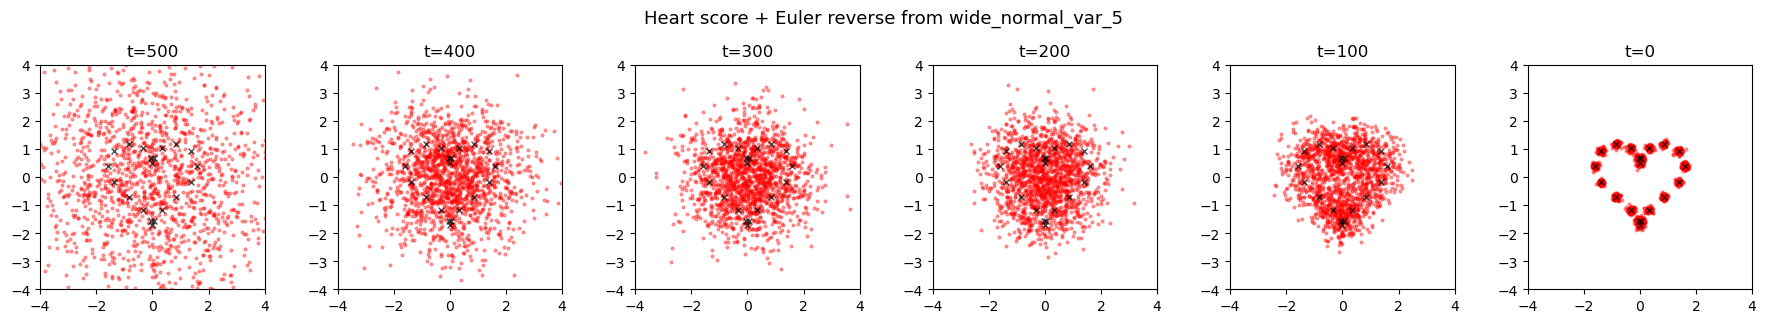

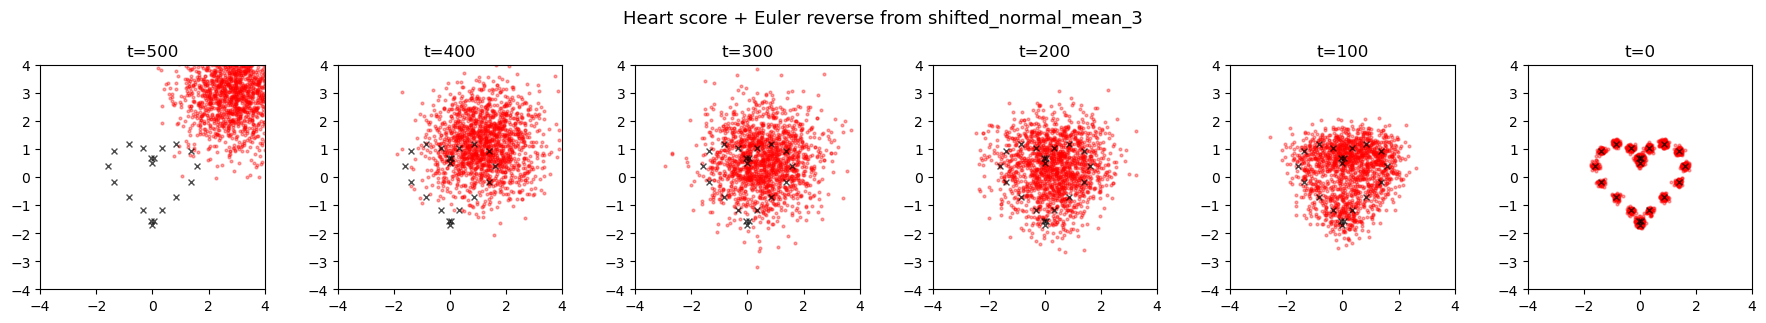

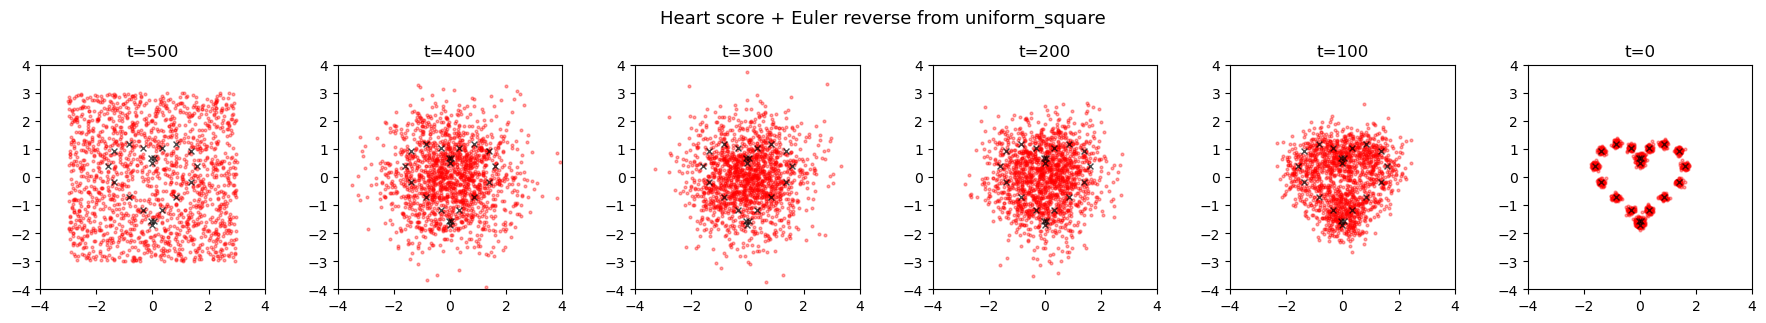

In [7]:
reverse_trajs = {}
for name, x_T in initials.items():
    reverse_trajs[name] = reverse_euler(x_T, t_arr, heart_score)

for name, traj in reverse_trajs.items():
    plot_steps(traj, steps=SAVE_STEPS, order="desc", color="red", title=f"Heart score + Euler reverse from {name}")


## 최종 복원 결과 비교

`t=0`에서의 결과만 한 화면에 모아 봅니다. 검은 `x`는 heart GMM의 중심점입니다.


/var/folders/d6/klnztyj51h5d3y23pmnjp7v00000gn/T/ipykernel_72230/43846207.py:20: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/d6/klnztyj51h5d3y23pmnjp7v00000gn/T/ipykernel_72230/43846207.py:20: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/d6/klnztyj51h5d3y23pmnjp7v00000gn/T/ipykernel_72230/43846207.py:20: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/d6/klnztyj51h5d3y23pmnjp7v00000gn/T/ipykernel_72230/43846207.py:20: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/d6/klnztyj51h5d3y23pmnjp7v00000gn/T/ipykernel_72230/43846207.py:20: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/d6/klnztyj51h5d3y23pmnjp7v00000gn/T/ipykernel_7223

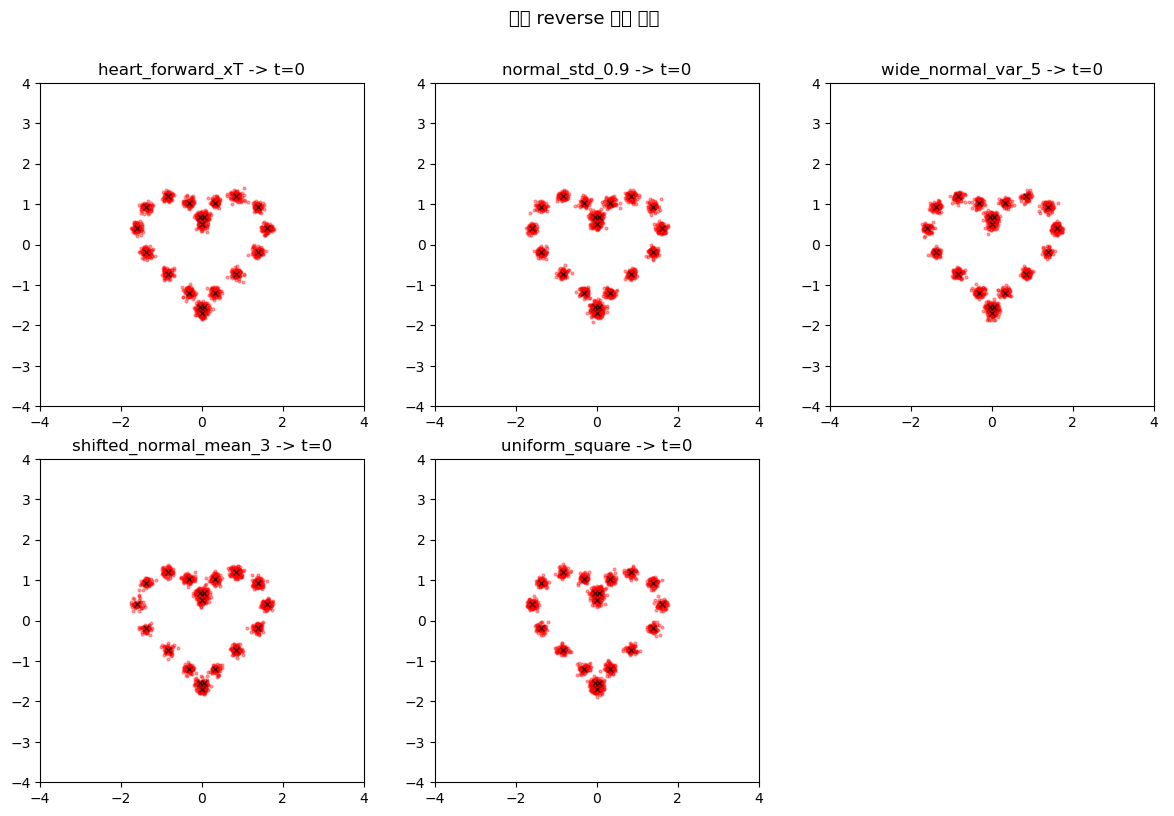

In [8]:
def plot_final_comparison(trajs, cols=3):
    names = list(trajs.keys())
    rows = int(np.ceil(len(names) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, name in zip(axes, names):
        pts = trajs[name][0]
        ax.scatter(*pts.T, s=4, alpha=0.35, c="red")
        ax.scatter(*heart_means.T, s=18, c="black", marker="x", linewidths=1.0, alpha=0.7)
        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)
        ax.set_aspect("equal")
        ax.set_title(f"{name} -> t=0")

    for ax in axes[len(names):]:
        ax.axis("off")

    fig.suptitle("최종 reverse 결과 비교", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


plot_final_comparison(reverse_trajs)


## 디버깅 통계

각 시작분포가 reverse 과정에서 어느 정도 중심으로 끌리는지 간단한 통계를 확인합니다.


In [9]:
debug_steps = [500, 400, 300, 200, 100, 50, 10, 1, 0]

for name, traj in reverse_trajs.items():
    print()
    print(name)
    print(f"{'t':>5} | {'N':>5} | {'mean_x':>8} | {'std_x':>8} | {'score_mag':>10} | {'drift_mag':>10}")
    print("-" * 65)

    for step in debug_steps:
        pts = traj[step]
        b = beta_fn(step)
        s = heart_score(pts, step)
        drift = b * (-0.5 * pts - s)
        print(
            f"{step:>5} | {len(pts):>5} | {pts.mean():>8.4f} | {pts.std():>8.4f} | "
            f"{np.linalg.norm(s, axis=1).mean():>10.4f} | {np.linalg.norm(drift, axis=1).mean():>10.4f}"
        )



heart_forward_xT
    t |     N |   mean_x |    std_x |  score_mag |  drift_mag
-----------------------------------------------------------------
  500 |  1600 |   0.0159 |   1.0007 |     1.2594 |     0.0126
  400 |  1600 |   0.0066 |   0.9830 |     1.2380 |     0.0100
  300 |  1600 |   0.0177 |   0.9840 |     1.2400 |     0.0076
  200 |  1600 |   0.0109 |   0.9846 |     1.2526 |     0.0052
  100 |  1600 |   0.0109 |   0.9701 |     1.6936 |     0.0057
   50 |  1600 |   0.0049 |   0.9670 |     3.5500 |     0.0071
   10 |  1600 |   0.0143 |   0.9580 |    13.4596 |     0.0067
    1 |  1600 |   0.0137 |   0.9571 |    16.9397 |     0.0024
    0 |  1600 |   0.0139 |   0.9567 |    17.2500 |     0.0017

normal_std_0.9
    t |     N |   mean_x |    std_x |  score_mag |  drift_mag
-----------------------------------------------------------------
  500 |  1600 |   0.0196 |   0.9005 |     1.1255 |     0.0113
  400 |  1600 |   0.0071 |   0.9846 |     1.2388 |     0.0100
  300 |  1600 |  -0.0092 |  